In [1]:
import pandas as pd
df = pd.read_csv("mock_lenses_hsc.csv")
df

,objID,objID_src,rot,x_lens,y_lens,q,PA,r_Einstein,z_source,z_lens,velDisp,x_source,y_source,boost,shear,shear_PA
0,1,1090,0,0.038127,-0.083938,0.832873,1.099377,2.454128,3.127611,0.730786,378.07416,-0.279477,-0.477602,-1.0,0.022431,0.911779
1,2,426,0,-0.082791,-0.109870,0.742644,1.852767,2.468242,5.798559,0.441585,329.32822,-0.074636,-0.380427,-3.0,0.059983,0.958381
2,3,2136,0,-0.054644,-0.008364,0.845785,2.936826,2.475322,4.785457,0.454826,333.96304,-0.133183,-0.277230,-3.0,0.038890,1.134869
3,4,7141,0,-0.030885,-0.070501,0.857919,2.483655,2.456651,4.792636,0.819645,369.14502,-0.133090,-0.034229,-4.0,0.005173,2.657499
4,5,7215,0,-0.038541,0.001391,0.899268,0.382301,2.497800,4.860585,0.703609,359.74615,-0.318418,-0.027564,-4.0,0.043490,1.112804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43728,51996,1083,1,0.012901,-0.058693,0.867499,1.836198,0.776824,0.827810,0.415259,248.21088,0.057228,-0.057947,-4.0,0.054220,2.249565
43729,51997,12,2,-0.001551,0.024924,0.808340,2.464540,0.756855,0.996663,0.422812,228.52315,-0.070151,-0.063773,-3.0,0.029062,2.235106
43730,51998,11,0,0.006303,-0.002664,0.750802,2.697964,0.792795,1.037593,0.484768,245.66832,-0.018803,-0.008539,-1.0,0.045575,2.531362
43731,51999,1273,0,0.046707,0.056492,0.853459,1.348237,0.786784,2.172062,0.494431,204.68020,0.006797,-0.021310,-1.0,0.041806,2.955045


In [2]:
import numpy as np
df['ex'] = np.cos(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)
df['ey'] = np.sin(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)

In [3]:
df['qq'] = np.sqrt((1 - np.sqrt(df.ex **2 + df.ey**2)) / (1 + np.sqrt(df.ex **2 + df.ey**2)) )
df['diff'] = df.q - df.qq

In [4]:
df['gamma1'] = np.cos(2 * df.shear_PA) * df.shear
df['gamma2'] = np.sin(2 * df.shear_PA) * df.shear

In [5]:
import os
os.chdir("/home/rcanameras/data/mock_lenses_hsc/")
# os.chdir("/home/mbatt")

In [6]:
folders = [f for f in os.listdir() if 'csv' not in f]

dict_im = {}
for fold in folders: 
    for file in os.listdir(fold):
        if '.fits' in file:
            objID = int(file.split('_')[1])
            dict_im[objID] = [fold + "/" + file]

In [7]:
df_im = pd.DataFrame(dict_im).T
df_im = df_im.reset_index()
df_im.columns = ["objID", "location"]

In [8]:
df_full = df.merge(df_im, on = "objID", how = 'left')

In [9]:
df_sample = df_full#.sample(n=2000, random_state=42)

In [10]:
import os
os.chdir("/home/mbatt")

In [11]:
dff = df_sample[['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey', 'location']]
dff = dff.set_index("location")

In [12]:
cols_to_norm = ['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey']
dff[cols_to_norm] = (dff[cols_to_norm] - dff[cols_to_norm].min()) / (dff[cols_to_norm].max() - dff[cols_to_norm].min())

In [13]:
dff = dff.sample(frac=1, random_state=42)

In [14]:
dff.to_csv('/home/mbatt/gravitational_lensing/ready_data.csv')

In [15]:
import pandas as pd
dff = pd.read_csv('/home/mbatt/gravitational_lensing/ready_data.csv', index_col = 0)

In [16]:
import os
os.chdir('/home/mbatt/gravitational_lensing')

In [17]:
from deep_learning_models import *
from deep_learning_models import LensDataset

In [18]:
import torch
from torch.utils.data import random_split

path_tensor = "/home/mbatt/data"
full_dataset = LensDataset_UNet(dff, path_tensor)

train_loader, val_loader, test_loader = full_dataset.split_data(training_pct = 0.6, # 60% for training
                                                                test_pct = 0.2, # 20% for test
                                                                batch_size = 32)

In [19]:
import os
os.chdir("/home/mbatt/gravitational_lensing")

In [20]:
# model = ResNetMini()   
model = ResNetHoliSmokes()
# model = BayesianResNetMini()
# model = UNet()
model = UNetThenResNet()
# model = UNetThenNN()

In [21]:
vv = viewer(model)
vv.show_model()

In [22]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 4,621,257
Trainable parameters: 4,621,257


In [23]:
from process_training import Trainer
import warnings
warnings.filterwarnings("ignore")

In [24]:
Train_model = Trainer(model = model,
                      learning_rate = 1e-3,
                      scheduler_coef = 0.1                  
)

In [25]:
# Train_model.run_unet_resnet(epochs = 100,
#                 training_set = train_loader, 
#                 validation_set = val_loader)

Train_model.run_unet_resnet(epochs = 100,
                training_set = train_loader, 
                validation_set = val_loader)

Epoch 1: train=0.0308, val=0.0254


KeyboardInterrupt: 

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import os

os.chdir("/home/mbatt/gravitational_lensing")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-5)

checkpoint = torch.load(f"{model.model_name}_20.pth", map_location=device)

model.load_state_dict(checkpoint["model"])
optimizer.load_state_dict(checkpoint["optimizer"])

start_epoch = checkpoint["epoch"] + 1

train_losses = checkpoint["train_losses"]
val_losses = checkpoint["val_losses"]


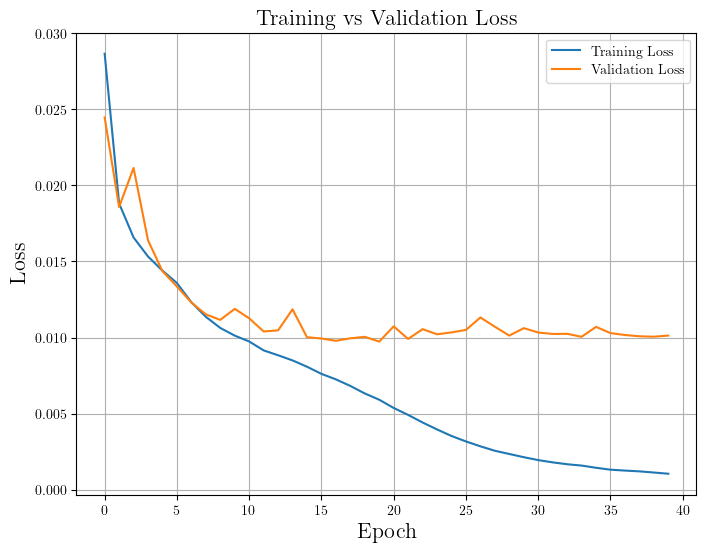

In [26]:
import matplotlib.pyplot as plt
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

plt.figure(figsize=(8,6))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch", fontsize = 16)
plt.ylabel("Loss", fontsize = 16)
plt.title("Training vs Validation Loss", fontsize = 16)
plt.legend()
plt.grid(True)
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/UNet_8_resnet_loss.png", dpi=300, bbox_inches="tight")
plt.show()


In [28]:
def rms(x):
    return torch.sqrt(torch.mean(x**2, dim=(-2, -1)))

def compute_noise(Liste, image, squarre):
    # Extract 5x5 corners
    tl = image[..., 0:squarre, 0:squarre]
    tr = image[..., 0:squarre, -squarre:]
    bl = image[..., -squarre:, 0:squarre]
    br = image[..., -squarre:, -squarre:]

    # RMS per corner → [B, 4]
    rms_tl = rms(tl)
    rms_tr = rms(tr)
    rms_bl = rms(bl)
    rms_br = rms(br)

    # Stack → [B, 4, 4]
    rms_all = torch.stack([rms_tl, rms_tr, rms_bl, rms_br], dim=-1)

    # Minimum RMS across corners → [B, 4]
    rms_min = rms_all.min(dim=-1).values

    Liste.append(rms_min.cpu())
    return Liste

In [29]:
model.eval()

Noise_t = []
Noise_p = []
Signal_t = []
Signal_p = []

squarre = 20
criterion = nn.MSELoss(reduction="none")

with torch.no_grad():
    for xb, yb in test_loader:
        
        xb, xout = xb[0].to(device), xb[1].to(device)
        yb, _ = yb[0].to(device), yb[1]

        # optimizer.zero_grad()

        # ---- Forward pass ----
#         out_lens = model.forward_unet(xb)
# #         out_lens = torch.cat([out_lens, xb - out_lens], dim=1)
#         outputs = model.forward_resnet(out_lens)
        
        Noise_t = compute_noise(Noise_t, xb, squarre)
        # Noise_p = compute_noise(Noise_p, out_lens, squarre)

        # Signal = sum of all pixels in xout → [B, 4]
        # signal_batch = out_lens.sum(dim=(-1, -2))
        # Signal_p.append(signal_batch.cpu())
        # print(xb.shape)
        signal_batch = xb.sum(dim=(-1, -2))
        Signal_t.append(signal_batch.cpu())

# Concatenate all batches
# Noise_p = torch.cat(Noise_p, dim=0) 
Noise_t = torch.cat(Noise_t, dim=0) 
# Noise[Noise == 0] = 0.2 # shape [N, 4]
# Signal_p = torch.cat(Signal_p, dim=0)  # shape [N, 4]
Signal_t = torch.cat(Signal_t, dim=0) # shape [N, 4]

# Compute ratio
# Ratio_p = Signal_p / Noise_p
Ratio_t = Signal_t / Noise_t

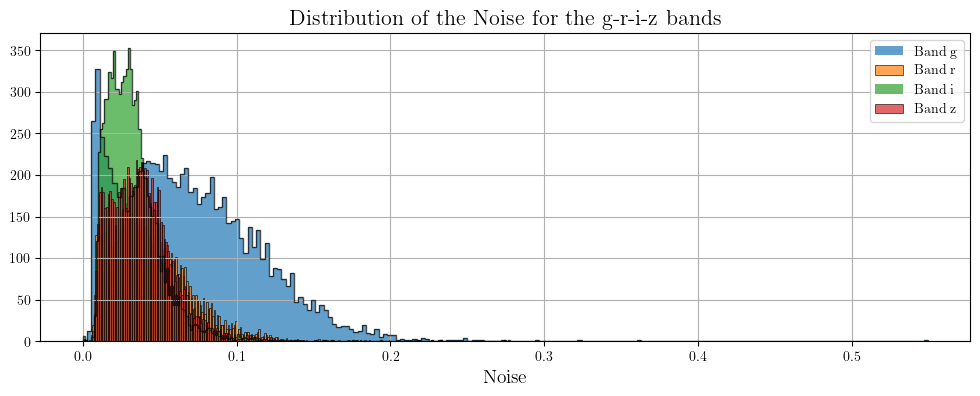

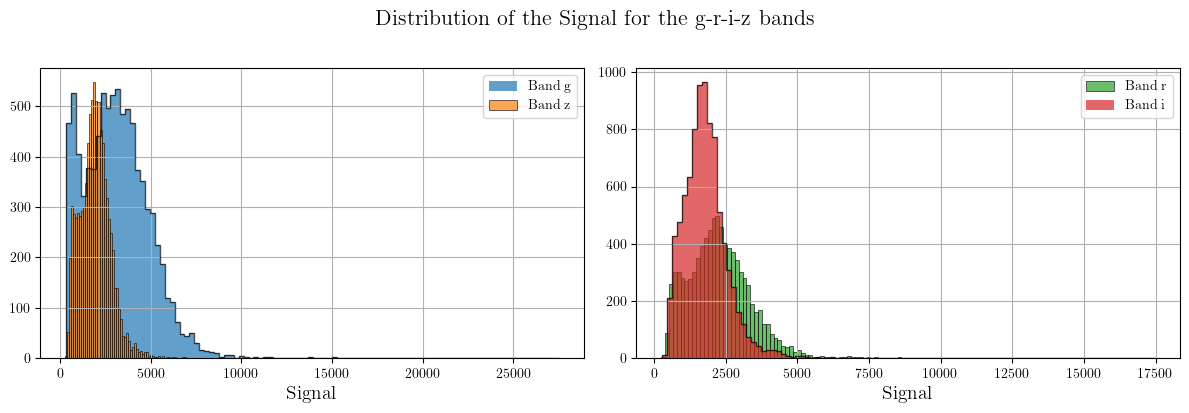

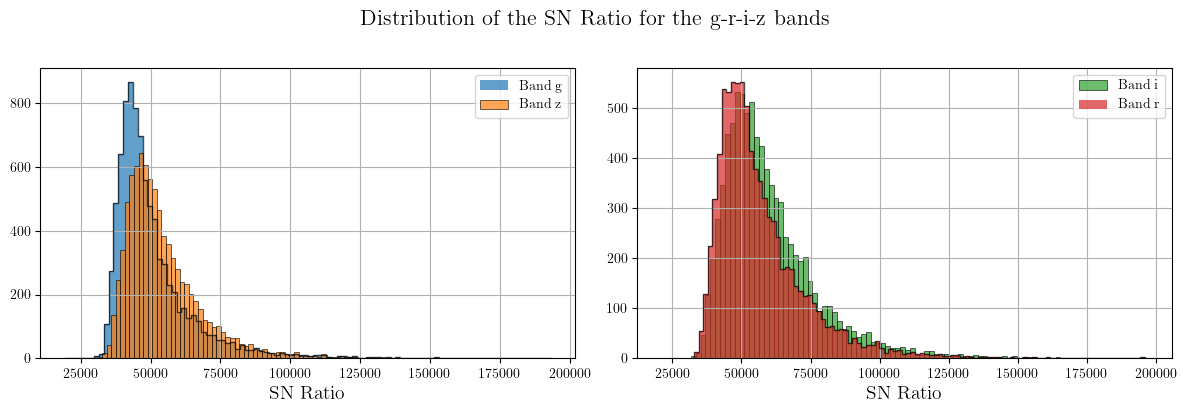

In [30]:
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]


fig, axis = plt.subplots(1,1, figsize = (12,4))
bandes = ['g', 'r', 'i', 'z']


ax = axis
# counts, bins, _ = ax.hist(Noise_t[:,0][Noise_t[:,0] < 0.6], bins=200, alpha=0.7, label = f'Band {bandes[0]}',histtype='step')
# # result = [x for x in bins[1:] for _ in range(2)]
# ax.plot(bins[:-1], counts, color='black', linewidth=0.7)
ax.hist(Noise_t[:,0][Noise_t[:,0] < 0.6], bins=200, alpha=0.7, label = f'Band {bandes[0]}')
ax.hist(Noise_t[:,0][Noise_t[:,0] < 0.6], bins=200, alpha=0.7, histtype='step', linewidth = 1, color = 'black')

ax.hist(Noise_t[:,1][Noise_t[:,1] < 0.6], bins= 200, label = f'Band {bandes[1]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)

ax.hist(Noise_t[:,2][Noise_t[:,2] < 0.6], bins=200, alpha=0.7, label = f'Band {bandes[2]}')
ax.hist(Noise_t[:,2][Noise_t[:,2] < 0.6], bins=200, alpha=0.7, histtype='step', linewidth = 1, color = 'black')

ax.hist(Noise_t[:,3][Noise_t[:,3] < 0.6], bins= 200, label = f'Band {bandes[3]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)

ax.set_title(f"Distribution of the Noise for the g-r-i-z bands",fontsize=16)
ax.grid(True)
ax.set_xlabel('Noise', fontsize=14)
ax.legend()
plt.show()

fig, axis = plt.subplots(1,2, figsize = (12,4))
ax = axis[0]
# [Signal_t[:,0] < 1500]
ax.hist(Signal_t[:,0][Signal_t[:,0] < 30000], bins=100, alpha=0.7, label = f'Band {bandes[0]}')
ax.hist(Signal_t[:,0][Signal_t[:,0] < 30000], bins=100, alpha=0.7, histtype='step', linewidth = 1, color = 'black')

ax.hist(Signal_t[:,3][Signal_t[:,3] < 30000], bins= 100, label = f'Band {bandes[3]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)
ax.grid(True)
ax.set_xlabel('Signal', fontsize=14)
ax.legend()

ax = axis[1]

ax.hist(Signal_t[:,1][Signal_t[:,1] < 30000], bins= 100, color = '#2ca02c', label = f'Band {bandes[1]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)

ax.hist(Signal_t[:,2][Signal_t[:,2] < 30000],color = '#d62728', bins=100, alpha=0.7, label = f'Band {bandes[2]}')
ax.hist(Signal_t[:,2][Signal_t[:,2] < 30000], bins=100, alpha=0.7, histtype='step', linewidth = 1, color = 'black')


ax.grid(True)
ax.set_xlabel('Signal',fontsize=14)
ax.legend()

fig.suptitle("Distribution of the Signal for the g-r-i-z bands",
             fontsize=16, y=1.02)
plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/sn_ratio.png", dpi=300, bbox_inches="tight")
plt.show()

fig, axis = plt.subplots(1,2, figsize = (12,4))
ax = axis[0]
ax.hist(Ratio_t[:,0][Ratio_t[:,0] < 200000], bins=100, alpha=0.7, label = f'Band {bandes[0]}')
ax.hist(Ratio_t[:,0][Ratio_t[:,0] < 200000], bins=100, alpha=0.7, histtype='step', linewidth = 1, color = 'black')
ax.hist(Ratio_t[:,3][Ratio_t[:,3] < 200000], bins= 100, label = f'Band {bandes[3]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)
ax.grid(True)
ax.set_xlabel('SN Ratio', fontsize=14)
ax.legend()

ax = axis[1]
ax.hist(Ratio_t[:,2][Ratio_t[:,2] < 200000], bins= 100, color = '#2ca02c', label = f'Band {bandes[2]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)

ax.hist(Ratio_t[:,1][Ratio_t[:,1] < 200000],color = '#d62728', bins=100, alpha=0.7, label = f'Band {bandes[1]}')
ax.hist(Ratio_t[:,1][Ratio_t[:,1] < 200000], bins=100, alpha=0.7, histtype='step', linewidth = 1, color = 'black')
ax.grid(True)
ax.set_xlabel('SN Ratio',fontsize=14)
ax.legend()

fig.suptitle("Distribution of the SN Ratio for the g-r-i-z bands",
             fontsize=16, y=1.02)
plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/sn_ratio.png", dpi=300, bbox_inches="tight")
plt.show()
    

In [31]:
from skimage.metrics import structural_similarity as ssim

model.eval()
preds_img = []
targets_img = []
inpute_img = []

pred_para = []
target_para = []
worsts_t = []
worsts_p = []

similarity = []
paths_list = []
i = 0

def normalize(y):
    M = np.array(y)
    return M/M.sum()

with torch.no_grad():
    for xb, yb in test_loader:
        
        xb, xout = xb[0].to(device), xb[1].to(device)
        yb, paths = yb[0].to(device), yb[1]

        optimizer.zero_grad()

        # ---- Forward pass ----
        out_lens = model.forward_unet(xb)
#         out_lens_b = torch.cat([out_lens, xb - out_lens], dim=1)
        outputs = model.forward_resnet(out_lens)

        simi = []
        for k in range(len(xout)):
            ss = []
            for i in range(4):
                M1 = normalize(xout[k][i].cpu())
                M2 = normalize(out_lens[k][i].cpu())
                # ss.append(ssim(M1, M2, data_range=1.0, full=True)[0])
                diff = M1 - M2
                mse = np.sqrt((diff**2).mean())
                ss.append(mse)
            similarity.append(ss)
        #     simi.append(ss[0])

        # idx_bad = np.where(np.array(simi) < 0.00019)[0]
        # if len(idx_bad) > 0:
        #     for i in idx_bad:
        #         preds_img.append(out_lens.cpu()[i])
        #         targets_img.append(xout.cpu()[i])
        #         inpute_img.append(xb.cpu()[i])
        #         paths_list.append(paths[i])
        #         worsts_t.append(yb.cpu()[i])
        #         worsts_p.append(outputs.cpu()[i])
            
        errors = np.abs(outputs.cpu()[:, 0] - yb.cpu()[:, 0])
        idx_bad = np.where(errors > (1.35)/(2.49995857 - 0.75001659))[0]
        
        if len(idx_bad) > 0:
            for i in idx_bad:
                preds_img.append(out_lens.cpu()[i])
                targets_img.append(xout.cpu()[i])
                inpute_img.append(xb.cpu()[i])
                paths_list.append(paths[i])
                worsts_t.append(yb.cpu()[i])
                worsts_p.append(outputs.cpu()[i])

        errors = np.abs(outputs.cpu()[:, 0] - yb.cpu()[:, 0])
        idx_bad = np.where(errors < 0.00004/(2.49995857 - 0.75001659))[0]
        
        if len(idx_bad) > 0:
            for i in idx_bad:
                preds_img.append(out_lens.cpu()[i])
                targets_img.append(xout.cpu()[i])
                inpute_img.append(xb.cpu()[i])
                paths_list.append(paths[i])
                worsts_t.append(yb.cpu()[i])
                worsts_p.append(outputs.cpu()[i])
        
        pred_para.append(outputs.cpu())
        target_para.append(yb.cpu())

# concatenate all batches
preds_img = torch.cat(preds_img)      
targets_img = torch.cat(targets_img)  
inpute_img = torch.cat(inpute_img)

# paths_list = torch.cat(paths_list)
target_para = torch.cat(target_para)  
pred_para = torch.cat(pred_para)
worsts_t = torch.stack(worsts_t)   # shape (K, 5)
worsts_p = torch.stack(worsts_p)
similarity = np.stack(similarity)

AttributeError: 'ResNetHoliSmokes' object has no attribute 'forward_unet'

In [ ]:
paths_list

In [ ]:
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# Convert to numpy
true_value = target_para.cpu().numpy()
pred_value = pred_para.cpu().numpy()

# --- DENORMALIZATION ---
true_value = true_value * (df_max - df_min) + df_min
pred_value = pred_value * (df_max - df_min) + df_min
worsts_t = worsts_t * (df_max - df_min) + df_min
worsts_p = worsts_p * (df_max - df_min) + df_min

In [ ]:
worsts_t_np = worsts_t.cpu().numpy()
worsts_p_np = worsts_p.cpu().numpy()
for i in range(len(worsts_t)):
    true_val = worsts_t_np[i][0]
    pred_val = worsts_p_np[i][0]
    print(f"True r_einstein : {true_val:.4f}, Prediction r_einstein: {pred_val:.4f}, obj_id : {paths[i].split('/')[1]}")

In [ ]:
sd = similarity[:, 0]
vrai = true_value[:, 0]
tries = pred_value[:, 0]
pd.DataFrame({'Similarity':sd, 'True Value':vrai, 'Prediction':tries}).sort_values(by = 'Similarity')

In [ ]:
Ratio_t.shape

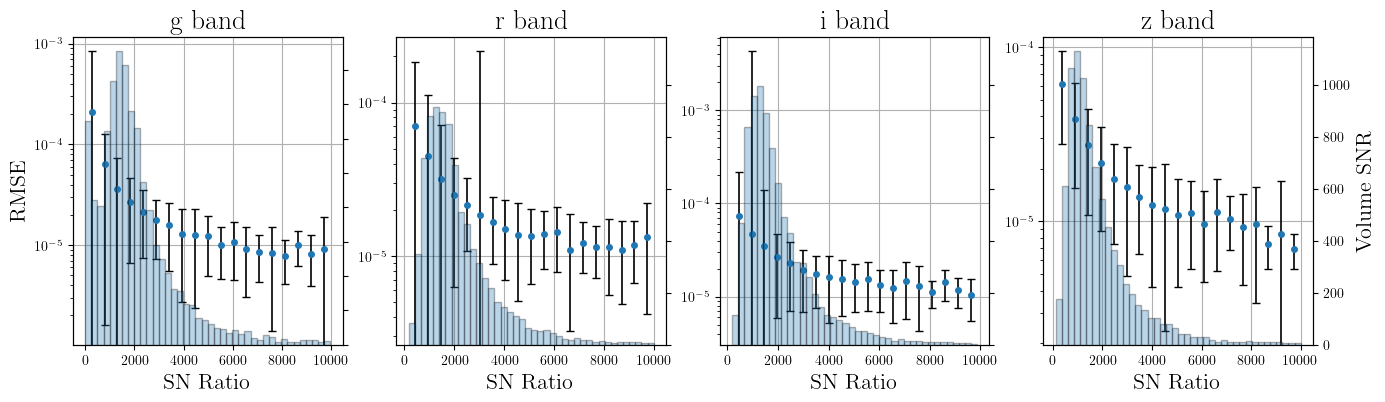

In [52]:
from matplotlib.ticker import FuncFormatter

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

twin_axes = []

for k in range(4):
    ax = axes[k]

    # --- your data prep ---
    x = Ratio_t[:, k].cpu().numpy()
    mask = (x < 10000)
    x = x[mask]

    residuals = similarity[:, k]
    residuals = residuals[mask]

    # --- binning ---
    bins = np.linspace(x.min(), x.max(), 20)
    bin_idx = np.digitize(x, bins)

    medians = []
    sigma1_low = []
    sigma1_high = []
    sigma3_low = []
    sigma3_high = []
    bin_centers = []

    for b in range(1, len(bins)):
        bin_mask = bin_idx == b
        if np.sum(bin_mask) < 3:
            continue

        r = residuals[bin_mask]
        med = np.median(r)
        std = np.std(r)

        medians.append(med)
        sigma1_low.append(med - std)
        sigma1_high.append(med + std)
        sigma3_low.append(med - 3*std)
        sigma3_high.append(med + 3*std)
        bin_centers.append((bins[b] + bins[b-1]) / 2)

    bin_centers = np.array(bin_centers)

    # --- left axis ---
    ax.errorbar(
    bin_centers, medians,
    yerr=[np.array(medians) - np.array(sigma1_low),
          np.array(sigma1_high) - np.array(medians)],
    fmt='o', color='C0', markersize=4, linewidth=1.2,
    ecolor='black', elinewidth=1.2, capsize=3, label='Median $\pm 1 \sigma$')
        
    # ax.plot(bin_centers, sigma1_low, color="black", linewidth=1.2)
    # ax.plot(bin_centers, sigma1_high, color="black", linewidth=1.2)
    # ax.plot(bin_centers, sigma3_low, color="black", linewidth=1.2)
    # ax.plot(bin_centers, sigma3_high, color="black", linewidth=1.2)
    # ax.axhline(0, color="red", linestyle=":", linewidth=1.5)

    # ax.fill_between(bin_centers, sigma3_low, sigma3_high,
    #                 color='gray', alpha=0.3)
    # ax.fill_between(bin_centers, sigma1_low, sigma1_high,
    #                 color='salmon', alpha=0.7, hatch='///')

    # ax.plot(bin_centers, medians, color='C0', linewidth=2)
    ax.grid(True)

    # --- right axis (histogram) ---
    ax2 = ax.twinx()
    twin_axes.append(ax2)
    ax2.hist(x, bins=40, edgecolor='black', alpha=0.3)
    # ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0e}"))
    ax.set_yscale("log")

    # hide redundant ticks
    # if k != 0:
    #     ax.tick_params(labelleft=False)
    if k != 3:
        ax2.tick_params(labelright=False)
    if k == 3:
        ax2.set_ylabel('Volume SNR', fontsize = 16)

# share all right y-axes
for ax2 in twin_axes[1:]:
    ax2.sharey(twin_axes[3])

Bands = ['g', 'r', 'i', 'z']
for k in range(4):
    axes[k].set_title(f'{Bands[k]} band', fontsize = 20)
    axes[k].set_xlabel('SN Ratio', fontsize = 16)
axes[0].set_ylabel('RMSE', fontsize = 16)

plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/snr_rmse.png", dpi=300, bbox_inches="tight")
plt.show()


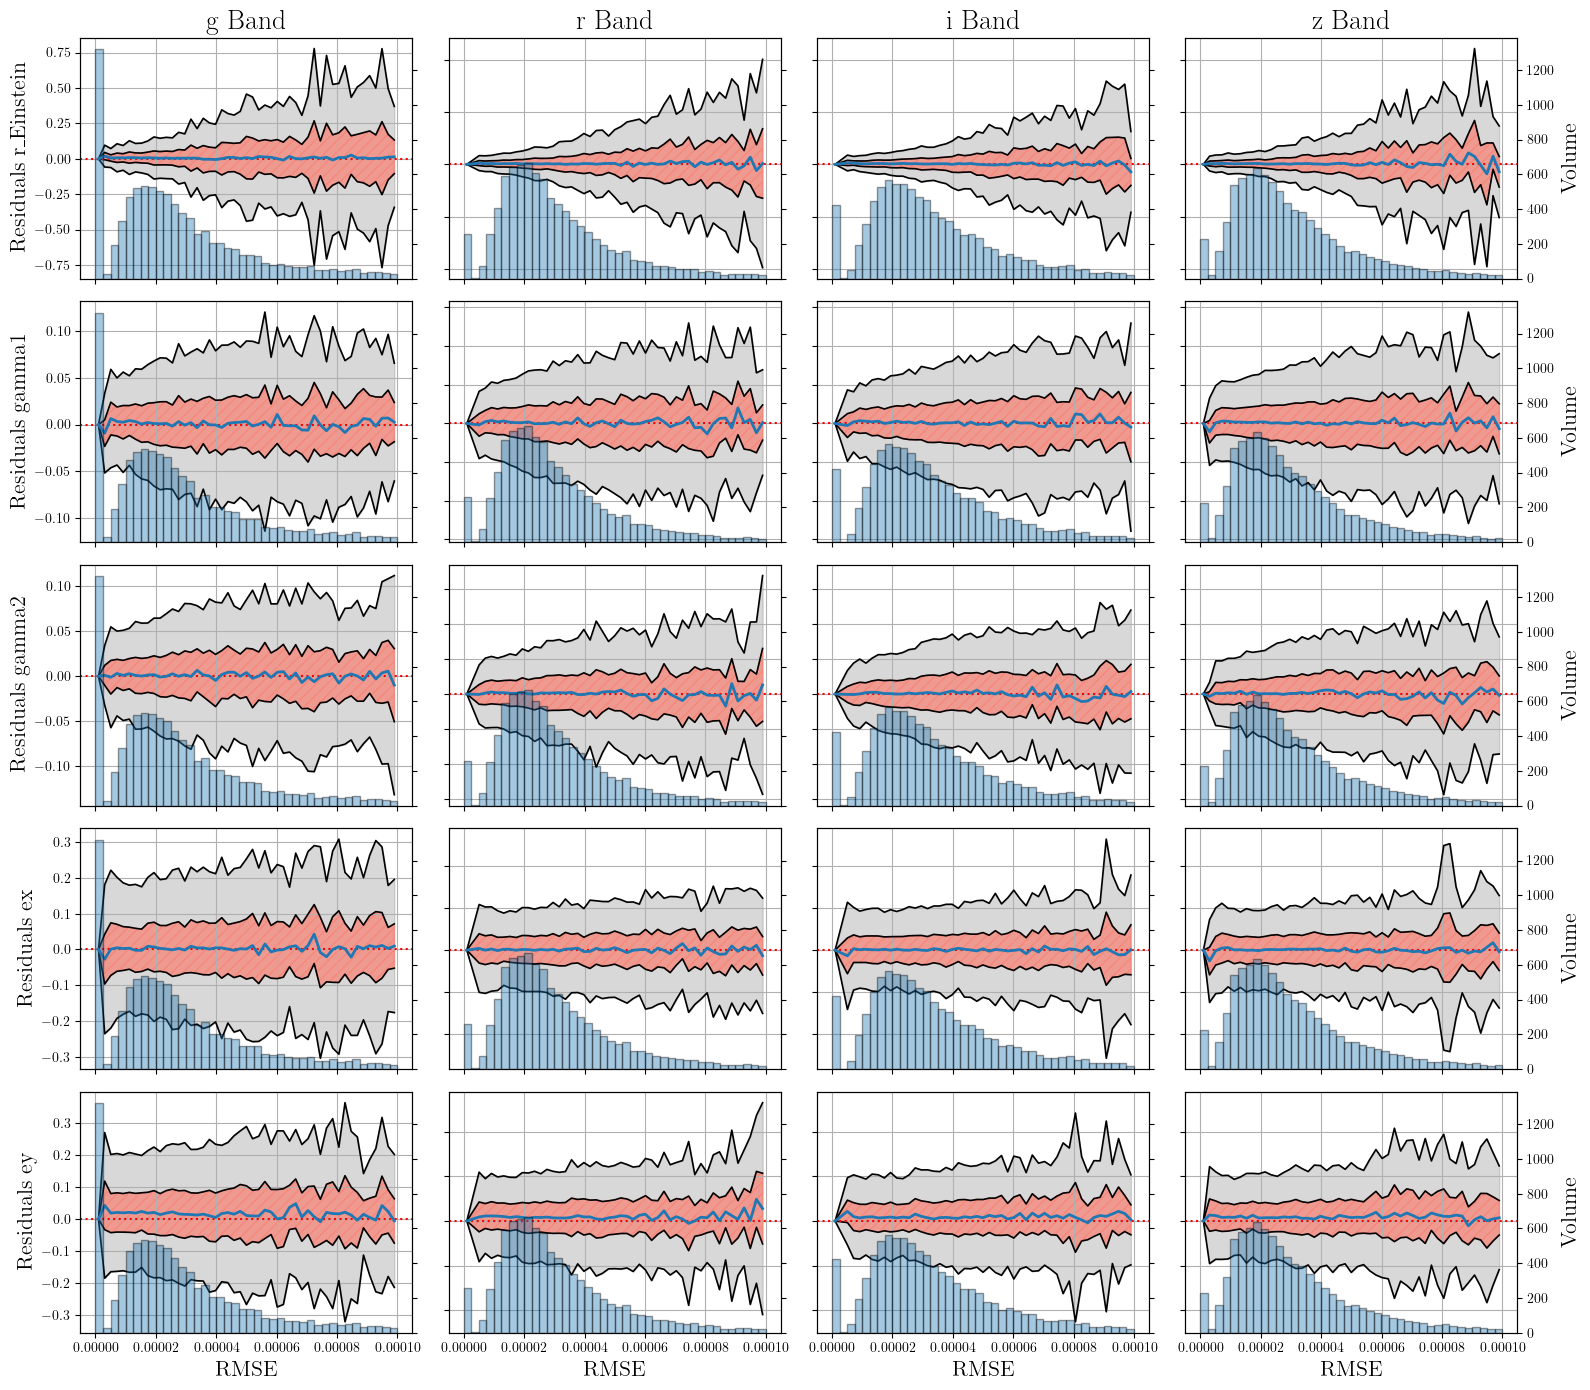

In [53]:
fig, axis = plt.subplots(5, 4, figsize=(16, 14))
bands = ['g', 'r', 'i', 'z']
names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]
twin_axes = []
left_axes = []
for k in range(20):
        x = similarity[:, k%4]
        mask = (x < 0.0001)   # keep only values in [-1, 1]
        x = x * mask
        residuals = true_value[:, k//4] - pred_value[:, k//4]
        residuals = residuals * mask
        bins = np.linspace(x.min(), x.max(), )
        bin_idx = np.digitize(x, bins)
        medians = []
        sigma1_low = []
        sigma1_high = []
        sigma3_low = []
        sigma3_high = []
        bin_centers = []
        for b in range(1, len(bins)):
            mask = bin_idx == b
            if np.sum(mask) < 3:
                continue  # skip empty bin
            r = residuals[mask]
            med = np.median(r)
            std = np.std(r)
            medians.append(med)
            sigma1_low.append(med - std)
            sigma1_high.append(med + std)
            sigma3_low.append(med - 3*std)
            sigma3_high.append(med + 3*std)
            bin_centers.append((bins[b] + bins[b-1]) / 2)
        bin_centers = np.array(bin_centers)
        ax = axis[k//4, k%4]
        # ax.errorbar(
        # bin_centers, medians,
        # yerr=[np.array(medians) - np.array(sigma1_low),
        #       np.array(sigma1_high) - np.array(medians)],
        # fmt='o', color='C0', markersize=4, linewidth=1.2,
        # ecolor='black', elinewidth=1.2, capsize=3, label='Median $\pm 1 \sigma$')
        ax.plot(bin_centers, sigma1_low, color="black", linewidth=1.2)
        ax.plot(bin_centers, sigma1_high, color="black", linewidth=1.2)
        ax.plot(bin_centers, sigma3_low, color="black", linewidth=1.2)
        ax.plot(bin_centers, sigma3_high, color="black", linewidth=1.2)
        ax.axhline(0, color="red", linestyle=":", linewidth=1.5)
        ax.fill_between(
            bin_centers, sigma3_low, sigma3_high,
            color='gray', alpha=0.3, label='3$\sigma$  band')
        ax.fill_between(
            bin_centers, sigma1_low, sigma1_high, hatch = '///',
            color='salmon', alpha=0.7, label='1$\sigma$ band')
        ax.plot(
            bin_centers, medians,
            color='C0', linewidth=2, label='Median')
        ax2 = ax.twinx()
        twin_axes.append(ax2)
        left_axes.append(ax)
        ax2.hist(x, bins=40, edgecolor='black', alpha=0.4)
        # ax.set_title(f"{bands[k%4]} Band", fontsize=16)
        ax.grid(True)
        if k%4 != 0:
            axis[k//4, k%4].sharey(axis[k//4,3])
    
        if k %4 == 0:
            ax.set_ylabel(f'Residuals {names[k//4]}', fontsize = 16)
        if k//4 == 0:
            ax.set_title(f'{bandes[k%5]} Band', fontsize = 20)
    #         ax.legend()
        if k%4 == 3:
            ax2.set_ylabel("Volume", fontsize = 16)
        if k//4 == 4:
            ax.set_xlabel('RMSE', fontsize = 16)
    #     ax.set_xticklabels([])
        if k//4 != 4: 
            ax.tick_params(labelbottom=False)
        if k%4 != 0:
            ax.tick_params(labelleft=False)
        if k%4 != 3:
            ax2.tick_params(labelright=False)
            
for ax2 in twin_axes[1:]:
    ax2.sharey(twin_axes[3])
axis[0,0].tick_params(labelleft=True)

plt.tight_layout()
plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/residual_mse.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
fig, axis = plt.subplots(5, 4, figsize=(16, 14), sharey=True)

twin_axes = [[None]*4 for _ in range(5)]

for k in range(20):

    # --- data prep ---
    x = similarity[:, k%4]
    mask = (x < 0.0004)
    x = x[mask]

    residuals = (true_value[:, k//4] - pred_value[:, k//4])
    residuals = residuals[mask]

    bins = np.linspace(x.min(), x.max(), 40)
    bin_idx = np.digitize(x, bins)

    medians = []
    sigma1_low = []
    sigma1_high = []
    sigma3_low = []
    sigma3_high = []
    bin_centers = []

    for b in range(1, len(bins)):
        bin_mask = bin_idx == b
        if np.sum(bin_mask) < 3:
            continue

        r = residuals[bin_mask]
        med = np.median(r)
        std = np.std(r)

        medians.append(med)
        sigma1_low.append(med - std)
        sigma1_high.append(med + std)
        sigma3_low.append(med - 3*std)
        sigma3_high.append(med + 3*std)
        bin_centers.append((bins[b] + bins[b-1]) / 2)

    bin_centers = np.array(bin_centers)

    # --- left axis ---
    ax = axis[k//4, k%4]
    ax.plot(bin_centers, sigma1_low, color="black", linewidth=1.2)
    ax.plot(bin_centers, sigma1_high, color="black", linewidth=1.2)
    ax.plot(bin_centers, sigma3_low, color="black", linewidth=1.2)
    ax.plot(bin_centers, sigma3_high, color="black", linewidth=1.2)
    ax.axhline(0, color="red", linestyle=":", linewidth=1.5)

    ax.fill_between(bin_centers, sigma3_low, sigma3_high,
                    color='gray', alpha=0.3)
    ax.fill_between(bin_centers, sigma1_low, sigma1_high,
                    color='salmon', alpha=0.7, hatch='///')

    ax.plot(bin_centers, medians, color='C0', linewidth=2)
    ax.grid(True)

    # --- right axis (histogram) ---
    ax2 = ax.twinx()
    twin_axes[k//4][k%4] = ax2
    ax2.hist(x, bins=40, edgecolor='black', alpha=0.4)

    # cosmetic cleanup
    if k%4 != 0:
        ax.tick_params(labelleft=False)
    if k%4 != 3:
        ax2.tick_params(labelright=False)
    if k//4 != 4:
        ax.set_xticklabels([])

# # --- SHARE ALL RIGHT Y-AXES ---
# all_twin = [twin_axes[i] for i in range(5)]
# for ax2 in all_twin[1:]:
#     ax2.sharey(all_twin[0])

plt.tight_layout()
plt.show()


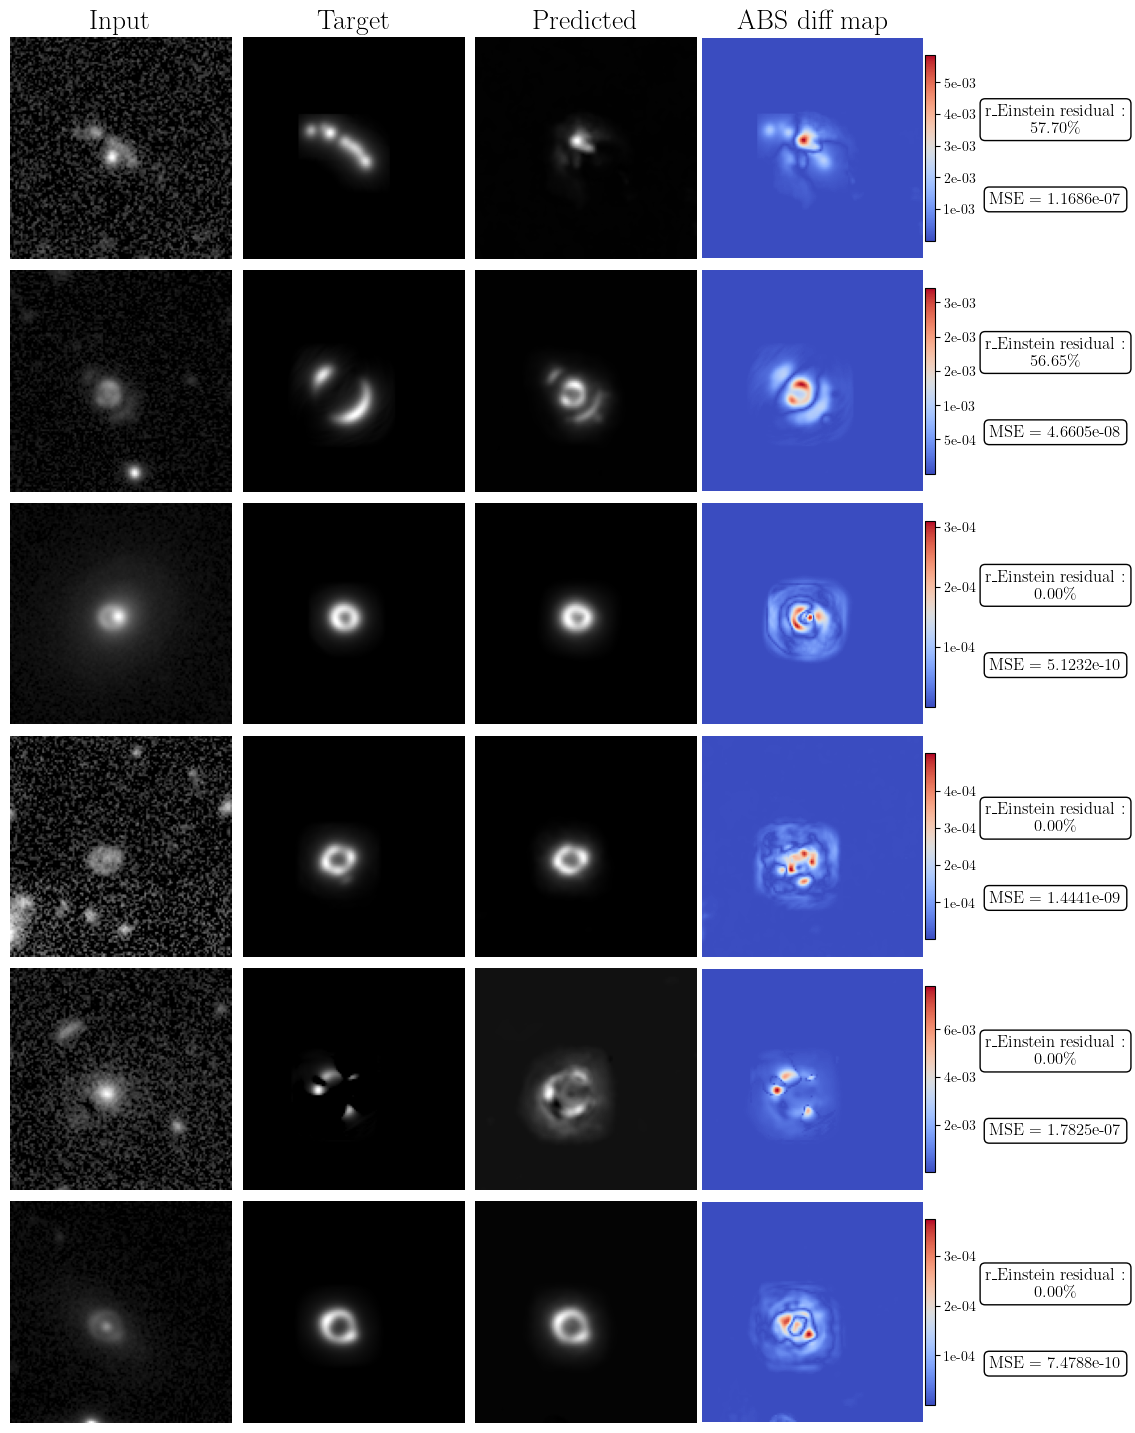

In [50]:
from skimage.metrics import structural_similarity as ssim

pred_np = preds_img.cpu().numpy()
targ_np = targets_img.cpu().numpy()
input_np = inpute_img.cpu().numpy()

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

# --- sinh transform ---
def transform(x):
    return x

def normalize(y):
    M = np.array(y)
    return M / M.sum()

pred_np = transform(pred_np)
targ_np = transform(targ_np)

w1 = 50 # image will be of dimension w2-w1 x w2-w1
bandes = ['g', 'r', 'i', 'z']

# --- Plot predictions (left) and targets (right) ---

T = 6
fig, axes = plt.subplots(T, 4, figsize=(12, 18))
fig.subplots_adjust(wspace=0.001, hspace=0.05)
index  = 0
for j in range(T):
    ax = axes[j, 1]
    ax.imshow(targ_np[index * 4][w1:-w1,w1:-w1], origin='lower', cmap='gray')
    pred = worsts_p_np[index][0]
    true = worsts_t_np[index][0]
    abs_res = abs(pred - true)
    pct_res = abs_res / abs(true) * 100
    ax.axis('off')
    ax = axes[j, 2]
    ax.imshow(pred_np[index * 4][w1:-w1,w1:-w1], origin='lower', cmap='gray')
    M1 = normalize(pred_np[index * 4][w1:-w1,w1:-w1])
    M2 = normalize(targ_np[index * 4][w1:-w1,w1:-w1])
    diff = M1 - M2
    diff_map = abs(diff)
    MSE_score = (diff**2).mean()
    # M1 = normalize(targ_np[index*4])
    # M2 = normalize(pred_np[index*4])
    # score, diff_map = ssim(M1, M2, data_range=1.0, full=True)
    ax.axis('off')
    ax = axes[j, 3]
    im = ax.imshow(diff_map, origin='lower', cmap='coolwarm')
    # cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02)
    cbar = fig.colorbar(im, ax=axes[j, 3], orientation='vertical', pad=0.01, fraction=0.04)
    cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0e}%"))
    # cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*100:.1f}%"))
    # cbar.set_label("Difference", fontsize=12)
    text = ('r_Einstein residual :\n'
    f'{pct_res:.2f}\%')
    ax.text(
        1.6, 0.7, text,
        ha='center', va='top',
        transform=ax.transAxes,
        fontsize=12,
        bbox=dict(
            facecolor='white',
            edgecolor='black',
            boxstyle='round,pad=0.3'
        )
    )
    ax.text(
        1.6, 0.3,
        f"MSE = {MSE_score:.4e}",
        ha='center', va='top',
        transform=ax.transAxes,
        fontsize=12,
        bbox=dict(
            facecolor='white',
            edgecolor='black',
            boxstyle='round,pad=0.3'
        )
    )
    # fig.colorbar(im, ax=ax)
    ax.axis('off')
    ax = axes[j, 0]
    ax.imshow(input_np[index * 4][w1:-w1,w1:-w1], origin='lower', cmap='gray')
    ax.axis('off')
    index += 1

axes[0,0].set_title('Input', fontsize = 20)
axes[0,1].set_title('Target', fontsize = 20)
axes[0,2].set_title('Predicted', fontsize = 20)
axes[0,3].set_title('ABS diff map', fontsize = 20)
# plt.tight_layout()
plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/mosaique.png", dpi=300, bbox_inches="tight")
plt.show()
    

In [51]:
batch_idx = 173
pred = preds_img[batch_idx]   # shape (4, 140, 140)
targ = targets_img[batch_idx]       # shape (4, 140, 140)
inpu = inpute_img[batch_idx]
obj_id = int(paths_list[batch_idx].split('_')[4])
true_value = target_para[batch_idx]
pred_value = pred_para[batch_idx]

IndexError: index 173 is out of bounds for dimension 0 with size 40

In [52]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pred_np = pred.cpu().numpy()
targ_np = targ.cpu().numpy()
inpu_np = inpu.cpu().numpy()

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

# --- sinh transform ---
def transform(x):
    return x**2

pred_np = transform(pred_np)
targ_np = transform(targ_np)
inpu_np = transform(inpu_np)

# --- compute MSE per band ---
mse_per_band = ((pred_np - targ_np) ** 2).mean(axis=(1,2))
global_mse = ((pred_np - targ_np) ** 2).mean()

print("MSE per band (g, r, i, z):", mse_per_band)
print("Global MSE:", global_mse)

bandes = ['g', 'r', 'i', 'z']

# --- Plot predictions (left) and targets (right) ---
fig, axes = plt.subplots(4, 3, figsize=(10, 14))

for i in range(4):
    # Prediction
    ax_pred = axes[i, 2]
    im_pred = ax_pred.imshow(pred_np[i], origin='lower', cmap='gray')
    fig.colorbar(im_pred, ax=ax_pred)
    ax_pred.set_title(f"Prediction – {bandes[i]} band", fontsize=16)
    ax_pred.axis('off')

    # Target
    ax_targ = axes[i, 1]
    im_targ = ax_targ.imshow(targ_np[i], origin='lower', cmap='gray')
    fig.colorbar(im_targ, ax=ax_targ)
    ax_targ.set_title(f"Target – {bandes[i]} band", fontsize=16)
    ax_targ.axis('off')
    
    # Inpute
    ax_inpu = axes[i, 0]
    im_inpu = ax_inpu.imshow(inpu_np[i], origin='lower', cmap='gray')
    fig.colorbar(im_inpu, ax=ax_inpu)
    ax_inpu.set_title(f"Input – {bandes[i]} band", fontsize=16)
    ax_inpu.axis('off')

plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/UNet_image_pred_test.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Optional: difference maps ---
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    diff = pred_np[i] - targ_np[i]
    ax = axes[i]
    im = ax.imshow(diff, origin='lower', cmap='coolwarm')
    fig.colorbar(im, ax=ax)
    ax.set_title(f"Diff (pred - target) – {bandes[i]}", fontsize=16)
    ax.axis('off')

plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/UNet_diff_image_pred.png", dpi=300, bbox_inches="tight")
plt.show()


# --- Optional: difference maps ---
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    pred = pred_np[i]
    targ = targ_np[i]
    eps = 1e-6
    pct = 2 * np.abs(pred - targ) / (np.abs(pred) + np.abs(targ) + eps)
    ax = axes[i]
    im = ax.imshow(pct, origin='lower', cmap='coolwarm')
#     fig.colorbar(im, ax=ax)
    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(f"Diff (pred - target) in % for {bandes[i]} band", fontsize=16)
    ax.axis('off')

plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/UNet_diff_image_pred_pct.png", dpi=300, bbox_inches="tight")

plt.show()



AttributeError: 'numpy.float64' object has no attribute 'cpu'

In [32]:
model.eval()
preds = []
targets = []
lens_only = []
paths = []

criterion = nn.MSELoss(reduction="none")

with torch.no_grad():
    for xb, yb in test_loader:   # <-- use test_loader here
        xb, xout = xb[0].to(device), xb[1].to(device)
        yb, ps = yb[0].to(device), yb[1]

        out_lens = model.forward_unet(xb)
#         out_lens_b = torch.cat([out_lens, xb - out_lens], dim=1)
        outputs = model.forward_resnet(out_lens)
        
        ms = ((out_lens - xout)**2).mean(dim=(2, 3))
        lens_only.append(ms)
        preds.append(outputs.cpu())
        targets.append(yb.cpu())
        paths += ps

# concatenate all batches
preds = torch.cat(preds)      # shape (N, 5)
targets = torch.cat(targets)  # shape (N, 5)
lens_only = torch.cat(lens_only)
df_final = pd.DataFrame({'Objid' : paths, 'Prediction_r_einstein' : preds.cpu().numpy()[:,0], 'Target_r_einstein' : targets.cpu().numpy()[:,0]})
# compute per-parameter MSE
loss = criterion(preds, targets)   # shape (N, 5)
mse = loss.mean(dim=0)             # shape (5,)

print("Per-parameter MSE:", mse)

# --- Compute R2 per parameter ---
y_true_np = targets.numpy()
y_pred_np = preds.numpy()

r2_scores = []
for i in range(5):
    ss_res = np.sum((y_true_np[:, i] - y_pred_np[:, i])**2)
    ss_tot = np.sum((y_true_np[:, i] - np.mean(y_true_np[:, i]))**2)
    r2 = 1 - ss_res / ss_tot
    r2_scores.append(r2)

print("Per-parameter R2:", r2_scores)

AttributeError: 'ResNetHoliSmokes' object has no attribute 'forward_unet'

In [31]:
df_final['Objid'] = df_final['Objid'].str.split('_').str[4].astype('int')

In [32]:
df_anom = df_final.merge(df, right_on = 'objID', left_on = 'Objid', how = 'left')

In [33]:
df_soucis = df_anom[df_anom.Status == 'ko']

AttributeError: 'DataFrame' object has no attribute 'Status'

In [ ]:
df_soucis

In [ ]:
df_soucis['res']  =abs(df_soucis.Prediction_r_einstein.values - df_soucis.Target_r_einstein.values)

In [ ]:
len(df_soucis)

In [91]:
df_soucs.sort_values(by = 'res')

,index,Objid,Prediction_r_einstein,Target_r_einstein,objID,Mean,Std,Status,res
38,1626,31435,0.408281,0.408160,31435,1.592838,87.613991,ko,0.000121
49,2103,22677,0.565540,0.565388,22677,1.547591,3.926300,ko,0.000152
50,2110,26776,0.488815,0.488972,26776,1.147378,23.761664,ko,0.000157
26,1178,47283,0.112476,0.112301,47283,1.242011,2.726022,ko,0.000175
75,2944,29837,0.435411,0.435161,29837,1.139018,1.663667,ko,0.000250
...,...,...,...,...,...,...,...,...,...
77,3028,2203,0.611621,0.968546,2203,1.235466,2.889691,ko,0.356925
120,4545,50585,0.420755,0.056853,50585,1.584188,60.186535,ko,0.363902
194,8251,22943,0.146174,0.557835,22943,1.162854,24.629783,ko,0.411662
100,3642,41017,0.657255,0.203629,41017,1.318236,57.461194,ko,0.453627


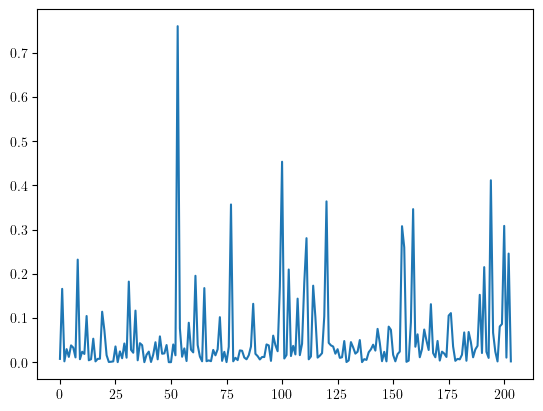

In [90]:
df_soucs = df_soucis
df_soucs = df_soucs.reset_index()
plt.plot(df_soucs.res)
plt.show()

In [92]:
(df_soucis.Prediction_r_einstein.values - df_soucis.Target_r_einstein.values)

AttributeError: 'numpy.ndarray' object has no attribute 'avg'

In [85]:
(df_soucis.Prediction_r_einstein.values - df_soucis.Target_r_einstein.values).mean()

-0.008580762

In [86]:
(df_soucis.Prediction_r_einstein.values- df_soucis.Target_r_einstein.values).std()

0.10901168

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# Min/max used for normalization
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# Convert to numpy
y_true = targets.numpy()
y_pred = preds.numpy()

# --- DENORMALIZATION ---
y_true_denorm = y_true * (df_max - df_min) + df_min
y_pred_denorm = y_pred * (df_max - df_min) + df_min

In [49]:
i = 0
names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

dr = pd.DataFrame({f'true {names[i]}' : y_true_denorm[:,i], f'pred {names[i]}' : y_pred_denorm[:,i]})
dr['res'] = abs(dr[f'true {names[i]}'] - dr[f'pred {names[i]}'])
dr.sort_values(by = 'res')


,true r_Einstein,pred r_Einstein,res
6464,2.240670,2.240672,0.000002
8189,1.724665,1.724650,0.000015
1403,1.880398,1.880378,0.000020
2606,1.354685,1.354726,0.000041
932,1.512550,1.512608,0.000058
...,...,...,...
1942,2.404738,1.078764,1.325974
2195,2.307589,0.977100,1.330488
6202,0.878724,2.249367,1.370642
1959,2.416942,1.014020,1.402921


In [49]:
loc = df_sample[df_sample.objID == obj_id ].location.values[0]

NameError: name 'obj_id' is not defined

In [50]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import os
import random

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

folder = "/home/rcanameras/data/mock_lenses_hsc"
file = os.path.join(folder, loc)
print("Opening:", file)

with fits.open(file) as hdul:
    images = [hdul[i].data for i in range(1, len(hdul))]
images = images[::2]
fig, axes = plt.subplots(1, 4, figsize=(15, 10))
bandes = ['g', 'r', 'i', 'z']

w1, w2 = 40, 160 # image will be of dimension w2-w1 x w2-w1

for ax, img, idx in zip(axes.ravel(), images, range(0, len(images))):
    img = img[w1:-w1,w1:-w1]
    im = ax.imshow(img, origin='lower', cmap='gray')
#     fig.colorbar(im, ax=ax)
    ax.set_title(f"Band  {bandes[idx//2]}")
    ax.axis('off')
    H, W = img.shape
    cx, cy = W/2, H/2

    # True Einstein radius (green)
    circle_true = plt.Circle((cx, cy), true_value[0]/0.168,
                             color='lime', fill=False, linewidth=2)
    ax.add_patch(circle_true)

    # Predicted Einstein radius (red)
    circle_pred = plt.Circle((cx, cy), pred_value[0]/0.168,
                             color='red', fill=False, linewidth=2)
    ax.add_patch(circle_pred)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(15, 10))
bandes = ['g', 'r', 'i', 'z']
for ax, img, idx in zip(axes.ravel(), images, range(0, len(images))):
    img = img[w1:-w1,w1:-w1]
    im = ax.imshow(img, origin='lower', cmap='gray')
#     fig.colorbar(im, ax=ax)
    ax.set_title(f"Band  {bandes[idx//2]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

with fits.open(file) as hdul:
    g = hdul[1].data
    r = hdul[3].data
    i = hdul[5].data
    z = hdul[7].data
    
R, G, B = i, r, g

def norm(x):
    x = x - np.nanmin(x)
    x = x / np.nanmax(x)
    return x

Rn, Gn, Bn = norm(R)[w1:-w1,w1:-w1], norm(G)[w1:-w1,w1:-w1], norm(B)[w1:-w1,w1:-w1]

rgb = np.dstack([Rn, Gn, Bn])

fig, axis = plt.subplots(1,2, figsize=(10,10))
axis[0].imshow(rgb, origin='lower')
axis[0].set_title("Lensing image")
axis[0].axis('off')

# Right image
axis[1].imshow(rgb, origin='lower')
axis[1].set_title("Radius Comparison")
axis[1].axis('off')

H, W = img.shape
cx, cy = W/2, H/2

# True Einstein radius (green)
circle_true = plt.Circle(
    (cx, cy),
    true_value[0] / 0.168,
    color='lime',
    fill=False,
    linewidth=2,
    label='True Radius'
)
axis[1].add_patch(circle_true)

# Predicted Einstein radius (red)
circle_pred = plt.Circle(
    (cx, cy),
    pred_value[0]/ 0.168,
    color='red',
    fill=False,
    linewidth=2,
    label='Predicted Radius'
)
axis[1].add_patch(circle_pred)

# Add legend
axis[1].legend(loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

NameError: name 'loc' is not defined

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# -----------------------------
# Helper: convert (ex, ey) → ellipse parameters
# -----------------------------
def ellipticity_to_axes(ex, ey, a_scale):
    e = np.sqrt(ex**2 + ey**2)            # ellipticity amplitude
    q = (1 - e) / (1 + e)                 # axis ratio b/a
    phi = 0.5 * np.arctan2(ey, ex)        # orientation
    a = a_scale                           # semi-major axis
    b = a * q                             # semi-minor axis
    return a, b, np.degrees(phi)

H, W = img.shape
cx, cy = W/2, H/2

# -----------------------------
# TRUE ellipse
# -----------------------------
ex_t = true_value[3]
ey_t = true_value[4]
a_scale_true = true_value[0] / 0.168   # same scale as your circle

a_t, b_t, phi_t = ellipticity_to_axes(ex_t, ey_t, a_scale_true)

# -----------------------------
# PRED ellipse
# -----------------------------
ex_p = pred_value[3]
ey_p = pred_value[4]
a_scale_pred = pred_value[0] / 0.168
a_p, b_p, phi_p = ellipticity_to_axes(ex_p, ey_p, a_scale_pred)


folder = "/home/rcanameras/data/mock_lenses_hsc"
file = os.path.join(folder, loc)
print("Opening:", file)

with fits.open(file) as hdul:
    images = [hdul[i].data for i in range(1, len(hdul))]
images = images[::2]    
fig, axes = plt.subplots(1, 4, figsize=(15, 10))
bandes = ['g', 'r', 'i', 'z']



for ax, img, idx in zip(axes.ravel(), images, range(0, len(images))):
    img = img[w1:-w1,w1:-w1]
    im = ax.imshow(img, origin='lower', cmap='gray')
#     fig.colorbar(im, ax=ax)
    ax.set_title(f"Band  {bandes[idx//2]}")
    ax.axis('off')
    
    ellipse_true = Ellipse(
    (cx, cy), width=2*a_t, height=2*b_t,
    angle=phi_t, edgecolor='lime', facecolor='none', linewidth=2)
    ax.add_patch(ellipse_true)

    ellipse_pred = Ellipse(
        (cx, cy), width=2*a_p, height=2*b_p,
        angle=phi_p, edgecolor='red', facecolor='none', linewidth=2
    )
    ax.add_patch(ellipse_pred)

plt.tight_layout()
plt.show()


fig, axis = plt.subplots(1,2, figsize=(10,10))
axis[0].imshow(rgb, origin='lower')
axis[0].set_title("Lensing image")
axis[0].axis('off')

# Right image
axis[1].imshow(rgb, origin='lower')
axis[1].set_title("Elipse Comparison")
axis[1].axis('off')


# Show the RGB image
ax.imshow(rgb, origin='lower')

ellipse_true = Ellipse(
    (cx, cy), width=2*a_t, height=2*b_t,
    angle=phi_t, edgecolor='lime', facecolor='none', linewidth=2, label = 'True'
)
axis[1].add_patch(ellipse_true)

ellipse_pred = Ellipse(
    (cx, cy), width=2*a_p, height=2*b_p,
    angle=phi_p, edgecolor='red', facecolor='none', linewidth=2, label = 'Predicted'
)
axis[1].add_patch(ellipse_pred)
axis[1].legend(loc='upper right', fontsize=12)

ax.set_aspect('equal')
plt.title("True vs Predicted Ellipticity Ellipses")
plt.axis('off')
plt.tight_layout()
plt.show()


NameError: name 'true_value' is not defined

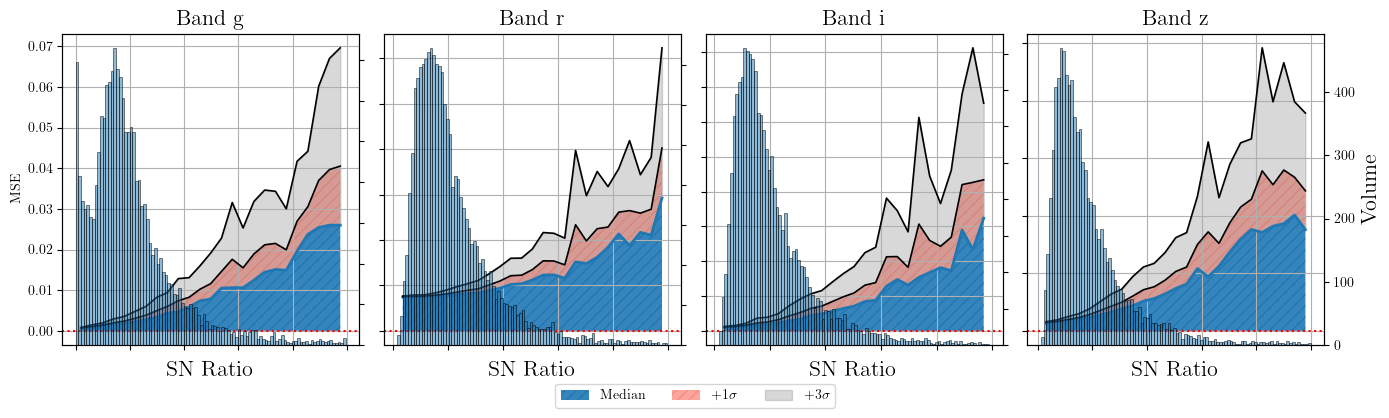

In [52]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

fig, axis = plt.subplots(1,4, figsize=(14,4))
bandes = ['g', 'r', 'i', 'z']
names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

# Number of bins for smoothing
nbins = 25

for i in range(4):

    ax = axis[i%4]
    ax2 = ax.twinx()
#     ax.set_xscale('log')

    # Extract x and y
    x = Ratio_t[:, i]
    y = lens_only[:,i].cpu().numpy()
    
    mask = x < 10000     # boolean mask
    x = x[mask]     # keep only x < 2000
    y = y[mask]     # keep corresponding y values

    # Create bins
    bins = np.linspace(x.min(), x.max(), nbins+1)
    centers = 0.5 * (bins[:-1] + bins[1:])

    # Compute median and sigmas inside each bin
    medians = []
    sigma1 = []
    sigma3 = []

    for j in range(nbins):
        mask = (x >= bins[j]) & (x < bins[j+1])
        if mask.sum() > 0:
            y_bin = y[mask]
            medians.append(np.median(y_bin))
            sigma1.append(np.std(y_bin))
            sigma3.append(3*np.std(y_bin))
        else:
            medians.append(np.nan)
            sigma1.append(np.nan)
            sigma3.append(np.nan)

    medians = np.array(medians)
    sigma1 = np.array(sigma1)
    sigma3 = np.array(sigma3)

    # Plot median line
    ax.plot(centers, medians, color='C0', linewidth=2)
    
    ax.fill_between(
        centers,
        0,
        medians,
        color="C0",
        alpha=0.9,
        hatch="///",          # crosshatch style
        linewidth=0.0,        # avoid thick borders around the whole patch
        label="Median"
    )
    
    ax.fill_between(
        centers,
        medians,
        medians + sigma1,
        color="salmon",
        alpha=0.7,
        hatch="///",          # crosshatch style
        linewidth=0.0,        # avoid thick borders around the whole patch
        label="$+1\sigma$"
    )
    
    # Plot ±3 sigma band
    ax.fill_between(centers,
                    medians,
                    medians + sigma3,
                    color='gray', alpha=0.3, label="$+3\sigma$")
    
#     ax.plot(centers, medians - sigma1, color="black", linewidth=1.2)
    ax.plot(centers, medians + sigma1, color="black", linewidth=1.2)
#     ax.plot(centers, medians - sigma3, color="black", linewidth=1.2)
    ax.plot(centers, medians + sigma3, color="black", linewidth=1.2)
    ax.axhline(0, color="red", linestyle=":", linewidth=1.5)


    ax.grid(True)
    
    ax2.hist(x, bins=100, alpha=0.5,edgecolor='black',linewidth=0.7, label = "SN Ratio")

    if i %4 == 0:
        ax.set_ylabel(f'MSE')
    if i//4 == 0:
        ax.set_title(f'Band {bandes[i%5]}', fontsize = 16)
#         ax.legend()
    if i%4 == 3:
        ax2.set_ylabel("Volume", fontsize = 16)

    ax.set_xlabel('SN Ratio', fontsize = 16)
#     ax.set_xticklabels([])
    if i//4 != 4: 
        ax.set_xticklabels([])
    if i%4 != 0:
        ax.set_yticklabels([])
    if i%4 != 3:
        ax2.set_yticklabels([])

plt.tight_layout()
handles, labels = axis[0].get_legend_handles_labels()

fig.legend(handles, labels,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.05),
           ncol=len(labels))
plt.show()


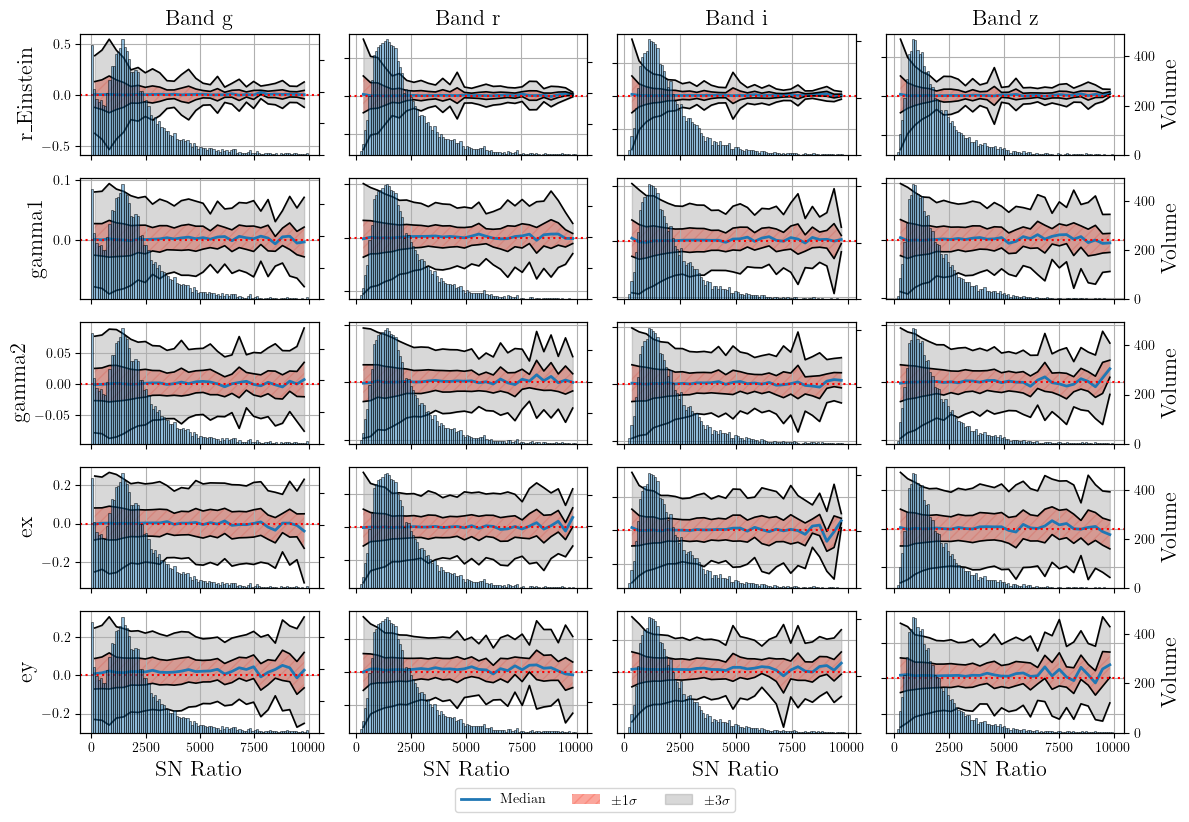

In [60]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

fig, axis = plt.subplots(5,4, figsize=(12,8))
bandes = ['g', 'r', 'i', 'z']
names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

# Number of bins for smoothing
nbins = 30

for i in range(20):

    ax = axis[i//4, i%4]
    ax2 = ax.twinx()
#     ax.set_xscale('log')

    # Extract x and y
    x = Ratio_t[:, i%4]
    y = y_true_denorm[:, i//4] - y_pred_denorm[:, i//4]
    
    mask = x < 10000          # boolean mask
    x = x[mask]     # keep only x < 2000
    y = y[mask]     # keep corresponding y values

    # Create bins
    bins = np.linspace(x.min(), x.max(), nbins+1)
    centers = 0.5 * (bins[:-1] + bins[1:])

    # Compute median and sigmas inside each bin
    medians = []
    sigma1 = []
    sigma3 = []

    for j in range(nbins):
        mask = (x >= bins[j]) & (x < bins[j+1])
        if mask.sum() > 0:
            y_bin = y[mask]
            medians.append(np.median(y_bin))
            sigma1.append(np.std(y_bin))
            sigma3.append(3*np.std(y_bin))
        else:
            medians.append(np.nan)
            sigma1.append(np.nan)
            sigma3.append(np.nan)

    medians = np.array(medians)
    sigma1 = np.array(sigma1)
    sigma3 = np.array(sigma3)

    # Plot median line
    ax.plot(centers, medians, color='C0', linewidth=2, label = "Median")
    
    ax.fill_between(
        centers,
        medians - sigma1,
        medians + sigma1,
        color="salmon",
        alpha=0.7,
        hatch="///",          # crosshatch style
        linewidth=0.0,        # avoid thick borders around the whole patch
        label="$\pm 1 \sigma$"
    )
    
    # Plot ±3 sigma band
    ax.fill_between(centers,
                    medians - sigma3,
                    medians + sigma3,
                    color='gray', alpha=0.3, label="$\pm 3 \sigma$")
    
    ax.plot(centers, medians - sigma1, color="black", linewidth=1.2)
    ax.plot(centers, medians + sigma1, color="black", linewidth=1.2)
    ax.plot(centers, medians - sigma3, color="black", linewidth=1.2)
    ax.plot(centers, medians + sigma3, color="black", linewidth=1.2)
    ax.axhline(0, color="red", linestyle=":", linewidth=1.5)


    ax.grid(True)
    
    ax2.hist(x, bins=100, alpha=0.5,edgecolor='black',linewidth=0.7, label = "SN Ratio")

    if i %4 == 0:
        ax.set_ylabel(f'{names[i//4]}', fontsize = 16)
    if i//4 == 0:
        ax.set_title(f'Band {bandes[i%5]}', fontsize = 16)
#         ax.legend()
    if i%4 == 3:
        ax2.set_ylabel("Volume", fontsize = 16)
    if i//4 == 4:
        ax.set_xlabel('SN Ratio', fontsize = 16)
#     ax.set_xticklabels([])
    if i//4 != 4: 
        ax.set_xticklabels([])
    if i%4 != 0:
        ax.set_yticklabels([])
    if i%4 != 3:
        ax2.set_yticklabels([])

plt.tight_layout()
handles, labels = axis[0,0].get_legend_handles_labels()

fig.legend(handles, labels,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.03),
           ncol=len(labels))
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Min/max used for normalization
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# Convert to numpy
y_true = targets.numpy()
y_pred = preds.numpy()

# --- DENORMALIZATION ---
y_true_denorm = y_true * (df_max - df_min) + df_min
y_pred_denorm = y_pred * (df_max - df_min) + df_min

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

plt.figure(figsize=(15, 8))
places = [(1,2), (5,6), (7,8), (9,10), (11,12)]

for i in range(5):

    # --- METRICS ---
    ss_res = np.sum((y_true_denorm[:, i] - y_pred_denorm[:, i])**2)
    ss_tot = np.sum((y_true_denorm[:, i] - np.mean(y_true_denorm[:, i]))**2)
    r2 = 1 - ss_res / ss_tot

    # Histogram comparison
    plt.subplot(3, 4, places[i][0])
    plt.hist(y_true_denorm[:, i], bins=30, alpha=0.6, label="Real")
    plt.hist(y_pred_denorm[:, i], bins=30, alpha=0.6, label="Predicted", edgecolor='black',linewidth=0.7)
    plt.title(f"{param_names[i]}", fontsize = 16)
    plt.legend()
    plt.grid(True)

    # Scatter plot real vs predicted
#     plt.subplot(5, 2, 2*i + 2)

    # Extract the variables
    x = y_true_denorm[:, i]
    y = y_pred_denorm[:, i]
    
    # Define number of bins
    nbins = 20

    # Compute bins
    bins = np.linspace(x.min(), x.max(), nbins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    medians = []
    sigmas = []

    for j in range(nbins):
        mask = (x >= bins[j]) & (x < bins[j+1])
        y_bin = y[mask]

        if len(y_bin) > 0:
            medians.append(np.median(y_bin))
            sigmas.append(np.std(y_bin))
        else:
            medians.append(np.nan)
            sigmas.append(np.nan)

    medians = np.array(medians)
    sigmas = np.array(sigmas)
    
    ax1 = plt.subplot(3, 4,  places[i][1])
    ax2 = ax1.twinx()

    # Plot median curve
    ax1.plot(bin_centers, medians, color="C0", lw=2, label="Median")
    ax1.set_ylabel("Predicted values", fontsize = 16)
    ax1.grid(True)

    # Plot ±1σ band
    ax1.fill_between(
        bin_centers,
        medians - sigmas,
        medians + sigmas,
        color="salmon",
        alpha=0.7,
        hatch="///",          # crosshatch style
        linewidth=0.0,        # avoid thick borders around the whole patch
        label="$\pm 1 \sigma$"
    )
    
    ax1.plot(bin_centers, medians - sigmas, color="black", linewidth=1.2)
    ax1.plot(bin_centers, medians + sigmas, color="black", linewidth=1.2)
    
    # 1:1 line
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    ax1.plot([min_val, max_val], [min_val, max_val], "k--", lw=1.5)
    ax2.hist(y_true_denorm[:, i], bins=30, alpha=0.3)
    ax2.set_ylabel("Volume", fontsize = 16)
    
    ax1.set_xlabel("Real values", fontsize = 16)
    ax1.legend()
    plt.title(f"Real vs Predicted: {param_names[i]}", fontsize = 16)
#     plt.grid(True)
#     plt.legend()


plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/UNet_8_resnet_1to1.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- Min/max used for normalization ---
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values
scale = df_max - df_min   # range for each parameter

# --- Convert to numpy ---
y_true = targets.numpy()
y_pred = preds.numpy()

# --- DENORMALIZATION ---
y_true_denorm = y_true * scale + df_min
y_pred_denorm = y_pred * scale + df_min

# --- Compute denormalised errors ---
error_denorm = y_pred_denorm - y_true_denorm

# --- Asymmetric statistics ---
medians = np.median(error_denorm, axis=0)
p16 = np.percentile(error_denorm, 16, axis=0)
p84 = np.percentile(error_denorm, 84, axis=0)

sigma_minus = medians - p16
sigma_plus  = p84 - medians

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

# --- Plot ---
fig, axes = plt.subplots(3, 2, figsize=(10, 8))
axes = axes.flatten()  
poss = [1,3,4,5,6]

for i in range(error_denorm.shape[1]):
    plt.subplot(3, 2, poss[i])
    plt.hist(error_denorm[:, i], bins=30, alpha=0.75,
             color="steelblue", edgecolor="black")
    plt.title(f"Residuals: {param_names[i]}")
    plt.xlabel("ypred - ytrue")
    plt.ylabel("Count")
    plt.grid(alpha=0.3)

    # --- Add text box with denormalised stats ---
    text = (
        f"median = {medians[i]:.4f}\n"
        f"$+ \sigma$ = {sigma_plus[i]:.4f}\n"
        f"$- \sigma$ = {sigma_minus[i]:.4f}"
    )

    plt.text(
        0.97, 0.95, text,
        transform=plt.gca().transAxes,
        fontsize=10,
        ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
    )

plt.tight_layout()
axes[1].axis("off")
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/unet_8_resnet_hist_residus.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Min/max used for normalization
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# Convert to numpy
y_true = targets.numpy()
y_pred = preds.numpy()

# --- DENORMALIZATION ---
y_true_denorm = y_true * (df_max - df_min) + df_min
y_pred_denorm = y_pred * (df_max - df_min) + df_min
error_denorm = y_pred_denorm - y_true_denorm

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

plt.figure(figsize= (15, 8))
places = [(1,2), (5,6), (7,8), (9,10), (11,12)]

for i in range(5):
    plt.subplot(3, 4, places[i][0])
    plt.scatter(y_true_denorm[:,i], error_denorm[:,i])
    plt.title(f"Residuals: {param_names[i]}")
    plt.xlabel("Real values")
    plt.ylabel("Residuals")
    plt.grid(alpha=0.3)
    
    # Extract the variables
    x = y_true_denorm[:, i]
    y = error_denorm[:, i]
    
    # Define number of bins
    nbins = 20

    # Compute bins
    bins = np.linspace(x.min(), x.max(), nbins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    medians = []
    sigmas = []

    for j in range(nbins):
        mask = (x >= bins[j]) & (x < bins[j+1])
        y_bin = y[mask]

        if len(y_bin) > 0:
            medians.append(np.median(y_bin))
            sigmas.append(np.std(y_bin))
        else:
            medians.append(np.nan)
            sigmas.append(np.nan)

    medians = np.array(medians)
    sigmas = np.array(sigmas)
    
    ax1 = plt.subplot(3, 4,  places[i][1])
    ax2 = ax1.twinx()

    # Plot median curve
    ax1.plot(bin_centers, medians, color="C0", lw=2, label="Median")
    ax1.set_ylabel("Residuals")
    ax1.grid(True)

    # Plot ±1σ band
    ax1.fill_between(
        bin_centers,
        medians - sigmas,
        medians + sigmas,
        color="salmon",
        alpha=0.7,
        hatch="///",          # crosshatch style
        linewidth=0.0,        # avoid thick borders around the whole patch
        label="±1σ"
    )
    
    ax1.plot(bin_centers, medians - sigmas, color="black", linewidth=1.2)
    ax1.plot(bin_centers, medians + sigmas, color="black", linewidth=1.2)
    ax2.hist(y_true_denorm[:, i], bins=30, alpha=0.3)
    ax2.set_ylabel("Volume")
    
    ax1.set_xlabel("Real values")
    ax1.legend()
    plt.title(f"Residuals: {param_names[i]}")

plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/unet_8_resnet_heteroscedastic.png", dpi=300, bbox_inches="tight")
plt.show()
